In [31]:
# %pip install numpy
# %pip install matplotlib
# %pip install networkx
# %pip install scipy
# %pip install pandas
# %pip install joblib

In [32]:
#Import Modules
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import truncnorm
import time
from IPython.display import clear_output
import pandas as pd
from joblib import Parallel, delayed

Parameters:
1. Number Of Agents
2. Number of levels? Departments? Company Structure
3. Base Game Payoffs
4. Base Productivity
5. Initial Conditions: Integrity, Trust


In [65]:
class Agent: 
    def __init__(self, id, level, integrity, trust, mutation, game):
        self.id = id
        self.level = level
        self.integrity = integrity
        self.trust = trust
        self.mutation = mutation
        self.utility = 0
        self.strategy = 0
        self.payoff = np.array(game, dtype=float, copy=True)
        self.game = game
        self.results = {}
        self.bosses = []
        self.peers = []
        self.underlings = []
        self.underlings_cooperating = 0
    

        #game functions:
    # 
    # 
    # 
    
    def get_opponents(self, opponents): #gets lost of opponent of type keywarg (used for play_game function in update)

        if isinstance(opponents, str):
            if opponents == 'bosses':
                return self.bosses
            elif opponents == 'peers':
                return self.peers
            elif opponents == 'underlings':
                return self.underlings
            else: 
                raise KeyError('Opponent must = bosses, peers or underlings' )
        else:
            raise TypeError('Opponent must a string and = bosses, peers or underlings')    

         
    def update_payoff(self): #transform game matrix into individual payoffs
        scale = np.clip(self.integrity + self.trust, -2, 2)
        payoff = self.game.copy()
        payoff[0][0] = payoff[0][0] * scale
        payoff[0][1] = payoff[0][1] * scale
        payoff[1][0] = payoff[1][0]
        payoff[1][1] = payoff[1][1]

        self.payoff = payoff
        
        return self.payoff
    
    def expected_opponent_strategy(self, t, fraction_corrupt, opponent): #find expected opponent strategy (right now based on fraction cooperating and trus)

        #base expected strategy on fraction of corrupt agents in the population and trust
        if t > 0: expected_strategy = (1-fraction_corrupt[-1])*self.trust #maybe better equation for this
        else: expected_strategy = .5
        return expected_strategy    

    def pick_strategy(self, t, fraction_corrupt, opponent): #pick strategy to play in the game
        #get expected opp strategy
        expected_strategy = self.expected_opponent_strategy(t, fraction_corrupt, opponent)

        #update payoff matrix
        payoff_matrix = self.update_payoff()

        #get utilities for every payoff
        uCC = payoff_matrix[0][0]
        uCD = payoff_matrix[0][1]
        uDC = payoff_matrix[1][0]
        uDD = payoff_matrix[1][1]

        #handle mixed strategies
        denominator = uDC - uCC + uCD - uDD
        if np.isfinite(denominator) and abs(denominator) > 1e-12:
            indifference_guess = (uCD - uDD) / denominator #Above this weight the opponent could put on cooperate D > C
        else:
            indifference_guess = 0.5

        # pick strategy
        s = 0
        biggest_row = []
        #add mutation chance (pick randomly)
        if np.random.rand() < self.mutation: # adds a random mutation/deviation from the "rational" strategy
            s = np.random.choice([0,1], p=[.5,.5])
            return s 
        else: #pick pick strategy
            if uCC > uDC and uCD > uDD: #Check for dominant strategy (can make these stochastic or use different heuristic)
                s = 0
                return s
            elif uCC < uDC and uCD < uDD:
                s = 1
                return s
            elif expected_strategy > indifference_guess : #Check for best expectation (mixed strategy)
                s = 1
                return s
            else:
                s = 0
                return s
            
    def punish(self, punish_rate):
        
        if np.random.rand() < punish_rate:
            self.integrity = truncnorm.rvs(-1, 1, loc=-0, scale=1)
            self.trust = truncnorm.rvs(-1, 1, loc=0, scale=1)

            return 1
        else: return 0
            
        
    #Dynamic variables
    #
    #
    #

    def d_utility(self, result):
        delta = .01 * self.payoff[result[0]][result[1]]
        if np.isfinite(delta):
            self.utility += delta
        return

    def d_trust(self, t):

        #Base on the utility that the oppenent recieved. If opponent defected and recieved higher utility, then trust should decrease 
        if t>0:
            last_round_strategies = list(self.results[t-1][0].values())

            peers_utility = []

            for peer in self.peers:
                peers_utility.append(peer.utility)
            if len(peers_utility) > 0:
                average_peer_utility = np.mean(peers_utility)
            else:
                average_peer_utility = None


            opp_def = 0
            result_count = 0

            for result in last_round_strategies:
                opp_def += result[1]
                result_count += 1


            if result_count > 0:

                fraction_def = opp_def/result_count
        
                if average_peer_utility > self.utility:
                    d_trust = .2*(np.tan(np.pi/2*(.5-fraction_def)))
                    if np.isfinite(d_trust):
                        self.trust = float(np.clip(self.trust + d_trust, -1, 1))
                    elif np.isposinf(d_trust):
                        self.trust = 1
                    elif np.isneginf(d_trust):
                        self.trust = -1
                    return
                else:
                    return
                
            

            
            
            
            
        


        

    
    


Option 1: generate agents with network -- I did this
Option 2: generate network then add agents
Option 3: generate agents then generate network

In [34]:
def generate_network(level_size, integrity_mean, trust_mean, mutation, game): #generate network with company structure

    G = nx.DiGraph()

    ceo = Agent(0, 'CEO', truncnorm.rvs(-1, 1, loc=integrity_mean, scale=1), truncnorm.rvs(-1, 1, loc=trust_mean, scale=1), mutation, game) #initialize top agent

    G.add_node(ceo.id, level=0, agent=ceo)
    nodes_this_level = [ceo.id]

    for level, size in enumerate(level_size):

        nodes_level = [] 

        for employee in range(size):

            id = len(G.nodes) #id for new node

            this_level = level + 1 #the current level is the index of the level_size list plus one (cause first level is ceo)

            #Initialize agent params
            integrity = truncnorm.rvs(-1, 1, loc=integrity_mean, scale=1)
            trust = truncnorm.rvs(-1, 1, loc=trust_mean, scale=1)

            #create employees at this level
            agent = Agent(id, this_level, integrity, trust, mutation, game)
            G.add_node(agent.id, level=this_level, agent=agent)

            #get list of employees this level
            nodes_level.append(agent)
            
            if this_level == 1: #if its the first level, the boss is the ceo

                G.add_edge(0, agent.id)

                #add to bosses and underlings attribute respectively
                agent.bosses.append(ceo)
                ceo.underlings.append(agent)

            else: #all other levels, the node randomly choses a boss from the previous level

                #pick random boss
                boss_id = np.random.choice([n for n, d in G.nodes(data=True) if d['level'] == this_level - 1])


                G.add_edge(boss_id, agent.id)

                #add to bosses and underlings attribute respectively
                agent.bosses.append(G.nodes[boss_id]['agent'])
                G.nodes[boss_id]['agent'].underlings.append(agent)

        #append employees to the level in nodes_this_level (used for peers)
        nodes_this_level.append(nodes_level)
        
        #make peer connections
        for employee in nodes_this_level[-1]:
            
            #for every node, connect to all peers
            for peer in nodes_this_level[-1]:

                if employee != peer: #avoid self edges

                    #add directional edges between both
                    G.add_edge(employee.id, peer.id)
                    G.add_edge(peer.id, employee.id)

                    #add to peer attribute
                    employee.peers.append(peer)
                    peer.peers.append(employee)
    return G

In [35]:
def initialize(level_size, integrity_mean, trust_mean, mutation):
  
    #prisoners dilemma matrix
    uCC = .75
    uCD = .1
    uDC = 1
    uDD = .5

    game = np.array([[uCC, uCD],
                     [uDC, uDD]])

    G = generate_network(level_size, integrity_mean, trust_mean, mutation, game)
    return G

In [36]:
def play_game(t, fraction_corrupt, node, punish_rate, opponents = str):

    opps = node.get_opponents(opponents)
    results = {}
    
    num_def = 0
    num_g = 0

    punish_count = 0

    for opponent in opps:

        opp_strat = 0
        node_strat = 0

        opp_strat = opponent.pick_strategy(t, fraction_corrupt, node)
        node_strat = node.pick_strategy(t, fraction_corrupt, opponent)

        node_result = (node_strat, opp_strat)
        opp_result = (opp_strat, node_strat)

        results[opponent.id] = node_result

        node.d_utility(node_result)
        opponent.d_utility(opp_result)

        if node_strat == 1:
            punish_count += node.punish(punish_rate)

        if opp_strat == 1:
            punish_count += opponent.punish(punish_rate)

        num_def += opp_strat + node_strat

        num_g += 2

        
        
        


    return results, num_def, num_g, punish_count

In [37]:
def update(G, t, fraction_corrupt, punish_rate):
    next_G = G
    results = []
    count_corrupt_t = 0
    games_count_t = 0
    punished_count = 0
    
    for n in G.nodes:

        node = G.nodes[n]['agent']

        #Play game with peers
        r_peers, num_defects_peers, num_games_peers, punish_count_peers = play_game(t, fraction_corrupt, node, punish_rate, 'peers')
        r_underlings, num_defects_underlings, num_games_underlings, punish_count_underlings = play_game(t, fraction_corrupt, node, punish_rate, 'underlings')
        

        node.results[t] = (r_peers, r_underlings)

        count_corrupt_t += num_defects_peers + num_defects_underlings

        results.append(node.results[t])

        games_count_t += num_games_peers + num_games_underlings

        punished_count += punish_count_peers + punish_count_underlings

    for n in G.nodes:

        node = G.nodes[n]['agent']

        node.d_trust(t)

    fraction_corrupt_t = count_corrupt_t/games_count_t
    return next_G, fraction_corrupt_t, results, punished_count, count_corrupt_t

In [38]:
def plot_network(G, trusts, utilities):

    def normalize_data(data):
        return (data - np.min(data)) / (np.max(data) - np.min(data))

    pos = nx.kamada_kawai_layout(G)

    levels = np.array([G.nodes[n]['level'] for n in G.nodes])

    # integrities = np.array([G.nodes[n]['agent'].integrity for n in G.nodes])

    # trusts = np.array([G.nodes[n]['agent'].trust for n in G.nodes])

    sizes = 1800 / (levels + 1)

    trust_network = plt.figure(figsize=(10, 7))

    nx.draw_networkx_edges(G, pos, alpha=0.35, arrows=True, arrowstyle='-|>', arrowsize=12)

    #nodes = nx.draw_networkx_nodes(G, pos, node_color=integrities, node_size=sizes, cmap='RdYlGn', vmin=-1, vmax=1)

    nodes = nx.draw_networkx_nodes(G, pos, node_color=trusts, node_size=sizes, cmap='RdYlGn', vmin=-1, vmax=1)

    nx.draw_networkx_labels(G, pos, font_size=8)

    #plt.colorbar(nodes, label='Integrity')
    plt.colorbar(nodes, label='Trust')

    plt.axis('off')
    
    plt.show()

    utility_network = plt.figure(figsize=(10, 7))

    nx.draw_networkx_edges(G, pos, alpha=0.35, arrows=True, arrowstyle='-|>', arrowsize=12)

    #nodes = nx.draw_networkx_nodes(G, pos, node_color=integrities, node_size=sizes, cmap='RdYlGn', vmin=-1, vmax=1)

    nodes = nx.draw_networkx_nodes(G, pos, node_color=normalize_data(utilities), node_size=sizes, cmap='viridis', vmin=0, vmax=1)

    nx.draw_networkx_labels(G, pos, font_size=8)

    #plt.colorbar(nodes, label='Integrity')
    plt.colorbar(nodes, label='Utility')

    plt.axis('off')

    plt.show()



In [39]:
def observe(G, model_data, trusts, utilities):

    #Plot network
    plot_network(G, trusts, utilities)

    #Plot Data

    #Fraction Corrupt
    fig1 = plt.Figure((10,6))
    plt.plot(model_data.fraction_corrupt)
    plt.show()

    #Mean Trust
    fig2 = plt.Figure((10,6))
    model_data.mean_trust.plot(kind = 'line', title = 'Mean Trust Over Time', xlabel = 'Time', ylabel = 'Mean Trust', label = 'Mean Trust')
    plt.show()

    #Mean Utility
    fig3 = plt.Figure((10, 6))
    plt.plot(model_data.mean_utility)
    plt.show()

    

In [40]:
def run(time_steps, level_size = [3, 9], integrity_mean=0, trust_mean=0, mutation=0, punish_rate=.1, plot = False, final_plot = True):
    N = np.sum(level_size)
    G = initialize(level_size, integrity_mean, trust_mean, mutation)
    fraction_corrupt = []

    model_data = pd.DataFrame(columns=['time_step', 'fraction_corrupt', 'count_corrupt', 'mean_trust', 'mean_utility', 'results', 'count_punished'])

    for t in range(time_steps):
        G, fraction_corrupt_t, results, punished_count, corrupt_count = update(G, t, fraction_corrupt, punish_rate)

        trusts = []

        for n in G.nodes: 
            trusts.append(G.nodes[n]['agent'].trust)

        mean_trust = np.mean(trusts)

        utilities = []

        for n in G.nodes: 
            utilities.append(G.nodes[n]['agent'].utility)

        mean_utility = np.mean(utilities)

        row_data = {
            'time_step': t,
            'fraction_corrupt': fraction_corrupt_t,
            'count_corrupt': corrupt_count,
            'mean_trust': mean_trust,
            'mean_utility': mean_utility,
            'results': results,
            'count_punished': punished_count

        }

        model_data.loc[len(model_data)] = row_data

        fraction_corrupt.append(fraction_corrupt_t)

        if plot:
            observe(G, model_data, trusts, utilities)
            clear_output(wait=True)
            time.sleep(.05)
            
    if final_plot:
        observe(G, model_data, trusts, utilities)
    
    return G, model_data


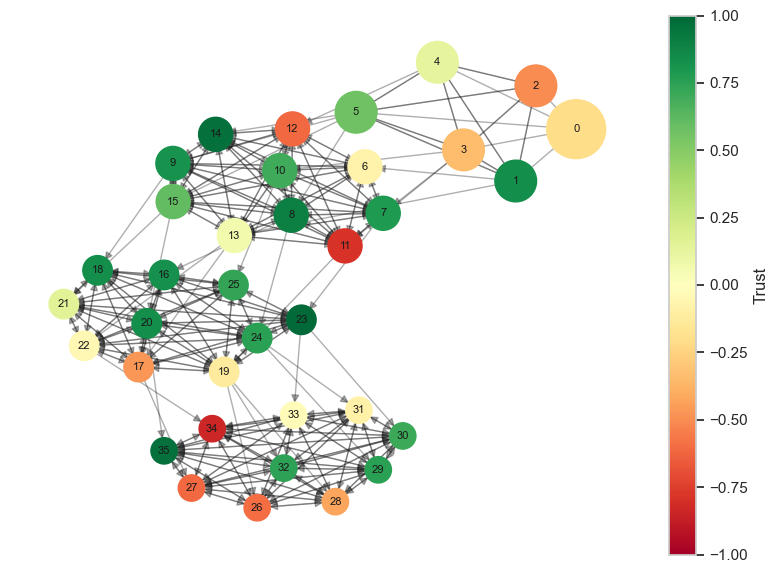

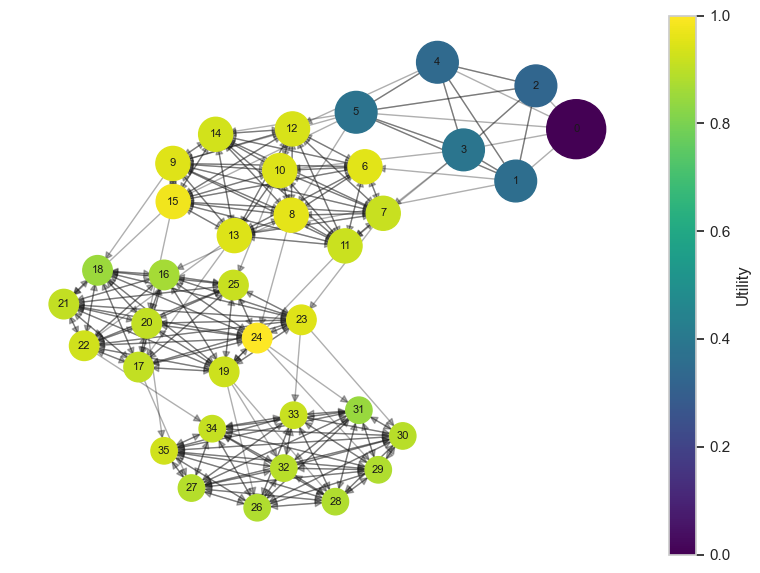

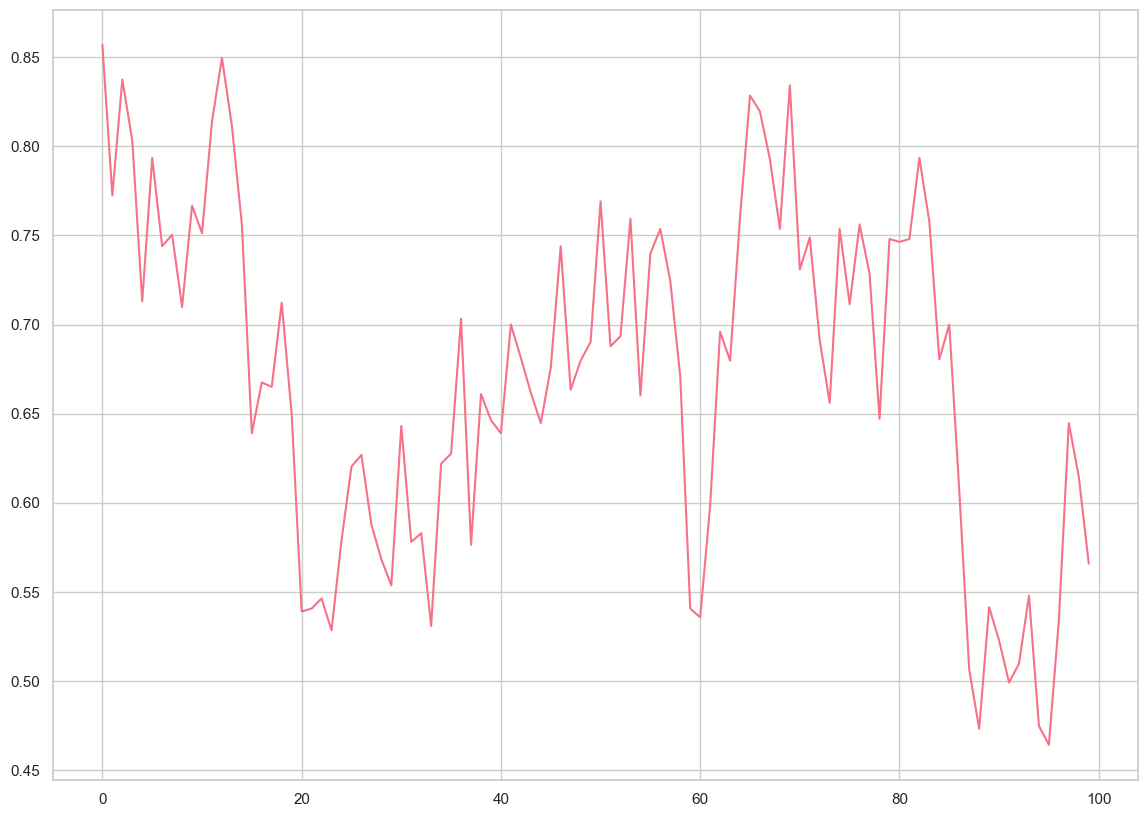

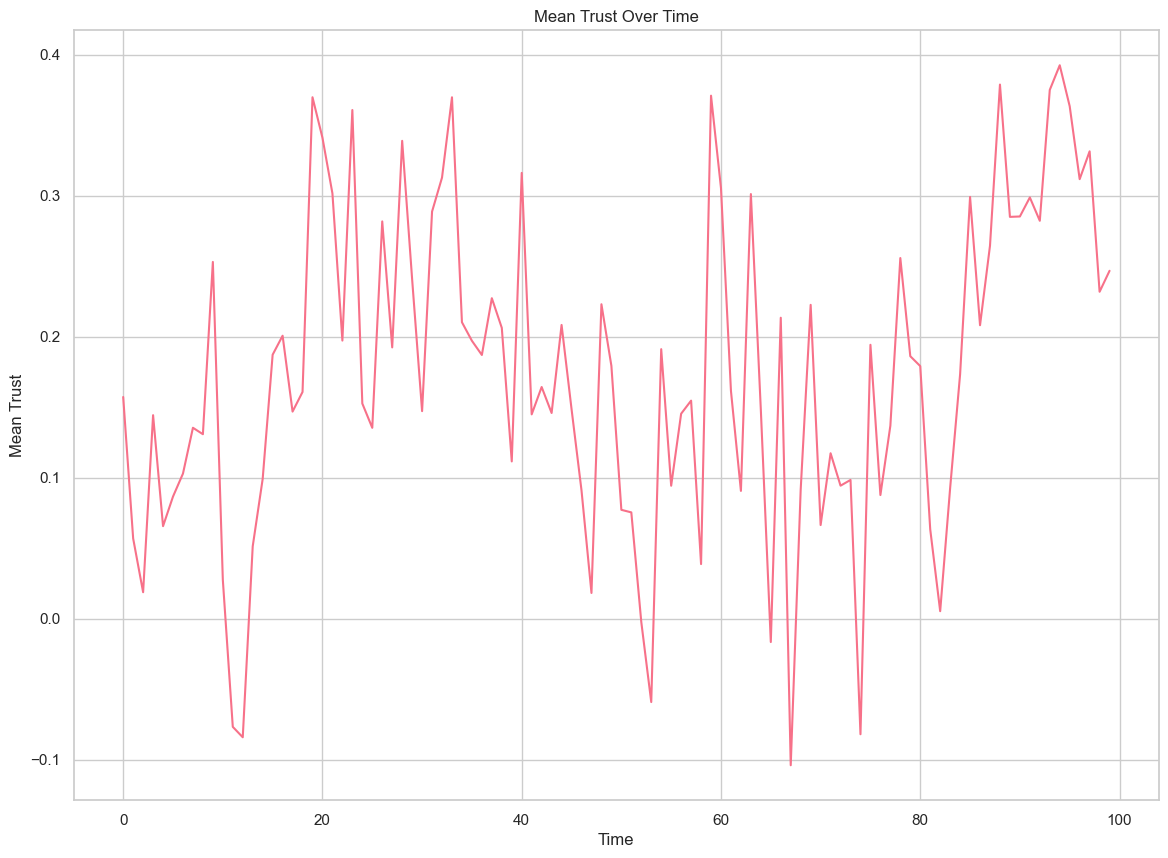

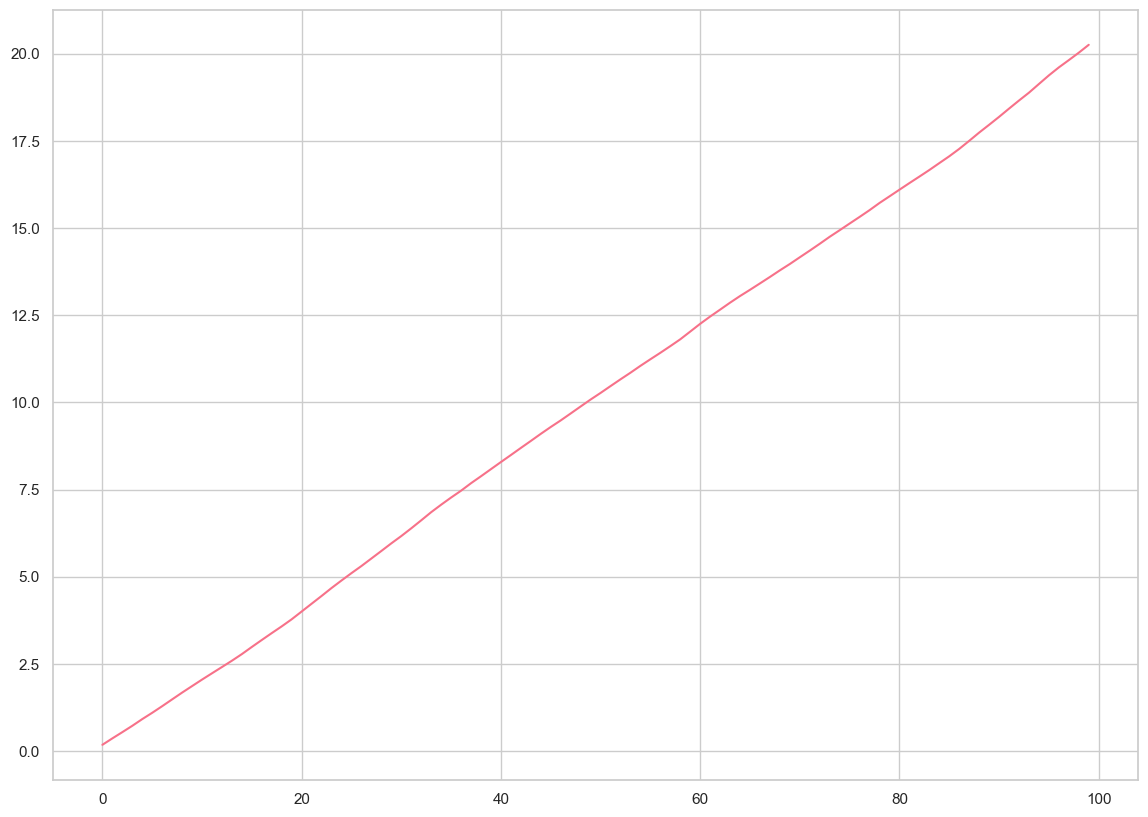

In [66]:
G, model_data = run(100, [5, 10, 10, 10], 0, 1, .1, .1, False)

In [42]:

display(model_data)

G.nodes[1]



,time_step,fraction_corrupt,count_corrupt,mean_trust,mean_utility,results,count_punished
0,0,0.662602,815,1.016312,0.205062,"[({}, {1: (0, 1), 2: (0, 1), 3: (0, 1), 4: (0,...",0
1,1,0.526829,648,0.932650,0.441188,"[({}, {1: (0, 1), 2: (0, 0), 3: (0, 1), 4: (0,...",0
2,2,0.821951,1011,0.915079,0.625893,"[({}, {1: (0, 1), 2: (0, 1), 3: (0, 1), 4: (np...",0
3,3,0.501626,617,0.812348,0.877254,"[({}, {1: (0, 1), 2: (0, 0), 3: (0, 1), 4: (0,...",0
4,4,0.778862,958,0.810366,1.065802,"[({}, {1: (0, 1), 2: (0, 0), 3: (0, 1), 4: (0,...",0
...,...,...,...,...,...,...,...
95,95,0.729268,897,0.022861,21.043621,"[({}, {1: (0, 1), 2: (0, 1), 3: (0, 1), 4: (0,...",0
96,96,0.726829,894,0.018971,21.270784,"[({}, {1: (0, 1), 2: (0, 1), 3: (0, 1), 4: (0,...",0
97,97,0.736585,906,0.013416,21.497384,"[({}, {1: (0, 1), 2: (0, 1), 3: (0, np.int64(0...",0
98,98,0.738211,908,0.009526,21.724900,"[({}, {1: (0, 1), 2: (0, 1), 3: (0, 1), 4: (0,...",0


{'level': 1, 'agent': <__main__.Agent at 0x119ef7250>}

agents ascribe strategy to all underlying based on perceptions
--> ascribe strategy to peers based on perceptions
--> ascribe strategy to superiors based on perceptions
Strategy expected payoffs are based on integrity, trust, and perceptions of others' strategies
cooperate cooperate results outcome: highest productivity for company
pay of boss is based on productivity of underlings 

agents update trust based on: person they can see (connected too) with highest utility: if that person is cooperating, they increase trust, if that person is defecting, they decrease trust.

agents update integrity on longer time scale (add later)

perception of others' strategies based on: trust (and history of interactions with them (add later))

In [43]:
# Cell 1 — New imports for LHS sweep
from scipy.stats.qmc import LatinHypercube
from tqdm.notebook import tqdm


In [62]:
# Cell 2 — LHS sweep function
def lhs_sweep(param_ranges, n_lhs_samples, n_runs_per_sample, time_steps, fixed_params, n_jobs=-1):
    """Run an LHS parameter sweep with stochastic repeats and return per-run outputs."""
    # Keep sweep dimensions in a stable order
    sweep_names = list(param_ranges.keys())
    bounds = [param_ranges[name] for name in sweep_names]

    # Validate sweep bounds and required params
    for name, (low, high) in zip(sweep_names, bounds):
        if low >= high:
            raise ValueError(f"Invalid range for '{name}': ({low}, {high})")
    required = ["level_size", "integrity_mean", "trust_mean", "mutation"]
    missing = [p for p in required if p not in fixed_params and p not in sweep_names]
    if missing:
        raise ValueError(f"Missing required parameters not swept or fixed: {missing}")

    # Draw LHS points in [0,1]^d and scale to each parameter range
    sampler = LatinHypercube(d=len(sweep_names))
    unit_samples = sampler.random(n=n_lhs_samples)
    scaled_samples = []
    for row in unit_samples:
        scaled_row = {}
        for i, name in enumerate(sweep_names):
            low, high = param_ranges[name]
            scaled_row[name] = low + row[i] * (high - low)
        scaled_samples.append(scaled_row)

    # Worker for one stochastic run at one LHS point
    def _run_one(sample_params, run_index):
        params = {**fixed_params, **sample_params}
        plot = params.get("plot", False)
        final_plot = params.get("final_plot", False)
        G, model_data = run(
            time_steps,
            params["level_size"],
            params["integrity_mean"],
            params["trust_mean"],
            params["mutation"],
            params["punish_rate"],
            plot,
            final_plot,
        )
        return {**sample_params, "run_index": run_index, "G": G, "model_data": model_data}

    # Execute n_runs_per_sample runs per LHS sample, with progress over total jobs
    all_results = []
    total_jobs = n_lhs_samples * n_runs_per_sample
    with tqdm(total=total_jobs, desc="LHS sweep") as pbar:
        for sample_params in scaled_samples:
            sample_results = Parallel(n_jobs=n_jobs)(
                delayed(_run_one)(sample_params, run_idx)
                for run_idx in range(n_runs_per_sample)
            )
            all_results.extend(sample_results)
            pbar.update(n_runs_per_sample)

    return all_results


In [45]:
%pip install -U jupyter ipywidgets tqdm


Note: you may need to restart the kernel to use updated packages.


In [67]:
# Cell 3 — Example usage
param_ranges = {
    "integrity_mean": (-1, 1),
    "trust_mean":     (-1, 1),
    "punish_rate":    (0, .2),  
    "mutation":       (0.0, 0.1),
}
fixed_params = {"level_size": [5, 10, 10, 10], "plot": False, "final_plot": False}

results = lhs_sweep(
    param_ranges      = param_ranges,
    n_lhs_samples     = 100,   # LHS points in parameter space
    n_runs_per_sample = 10,    # stochastic repeats per point
    time_steps        = 50,
    fixed_params      = fixed_params,
    n_jobs            = -1,
)

# Show a summary DataFrame of swept params + final fraction_corrupt
summary = pd.DataFrame([
    {**{k: r[k] for k in param_ranges}, "run": r["run_index"],
     "final_corruption": r["model_data"]["fraction_corrupt"].iloc[-1]}
    for r in results
])
display(summary)


LHS sweep:   0%|          | 0/1000 [00:00<?, ?it/s]

,integrity_mean,trust_mean,punish_rate,mutation,run,final_corruption
0,-0.431789,-0.612467,0.038996,0.030167,0,0.828455
1,-0.431789,-0.612467,0.038996,0.030167,1,0.914634
2,-0.431789,-0.612467,0.038996,0.030167,2,0.695122
3,-0.431789,-0.612467,0.038996,0.030167,3,0.628455
4,-0.431789,-0.612467,0.038996,0.030167,4,0.808943
...,...,...,...,...,...,...
995,-0.646785,0.783995,0.135126,0.041139,5,0.426016
996,-0.646785,0.783995,0.135126,0.041139,6,0.479675
997,-0.646785,0.783995,0.135126,0.041139,7,0.437398
998,-0.646785,0.783995,0.135126,0.041139,8,0.482927


In [52]:
display(results[0])



{'integrity_mean': np.float64(0.3130554854497527),
 'trust_mean': np.float64(-0.2567007225942777),
 'punish_rate': np.float64(0.17491122945607274),
 'mutation': np.float64(0.21751835032547867),
 'run_index': 0,
 'G': <networkx.classes.digraph.DiGraph at 0x3be07caf0>,
 'model_data':     time_step  fraction_corrupt  count_corrupt  mean_trust  mean_utility  \
 0           0          0.886992           1091   -0.337393      0.169690   
 1           1          0.902439           1110   -0.393465      0.338223   
 2           2          0.891870           1097   -0.444626      0.507507   
 3           3          0.868293           1068   -0.486367      0.673154   
 4           4          0.894309           1100   -0.512335      0.839154   
 5           5          0.905691           1114   -0.544833      1.007431   
 6           6          0.883740           1087   -0.577615      1.176017   
 7           7          0.889431           1094   -0.600089      1.344000   
 8           8          0

/var/folders/z0/72gknplj1v3dgx7k897dbd3m0000gn/T/ipykernel_18339/3844107193.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary, x='integrity_bin', y='final_corruption', ax=ax4, palette='Set2')
/var/folders/z0/72gknplj1v3dgx7k897dbd3m0000gn/T/ipykernel_18339/3844107193.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=summary, x='trust_bin', y='final_corruption', ax=ax5, palette='muted')


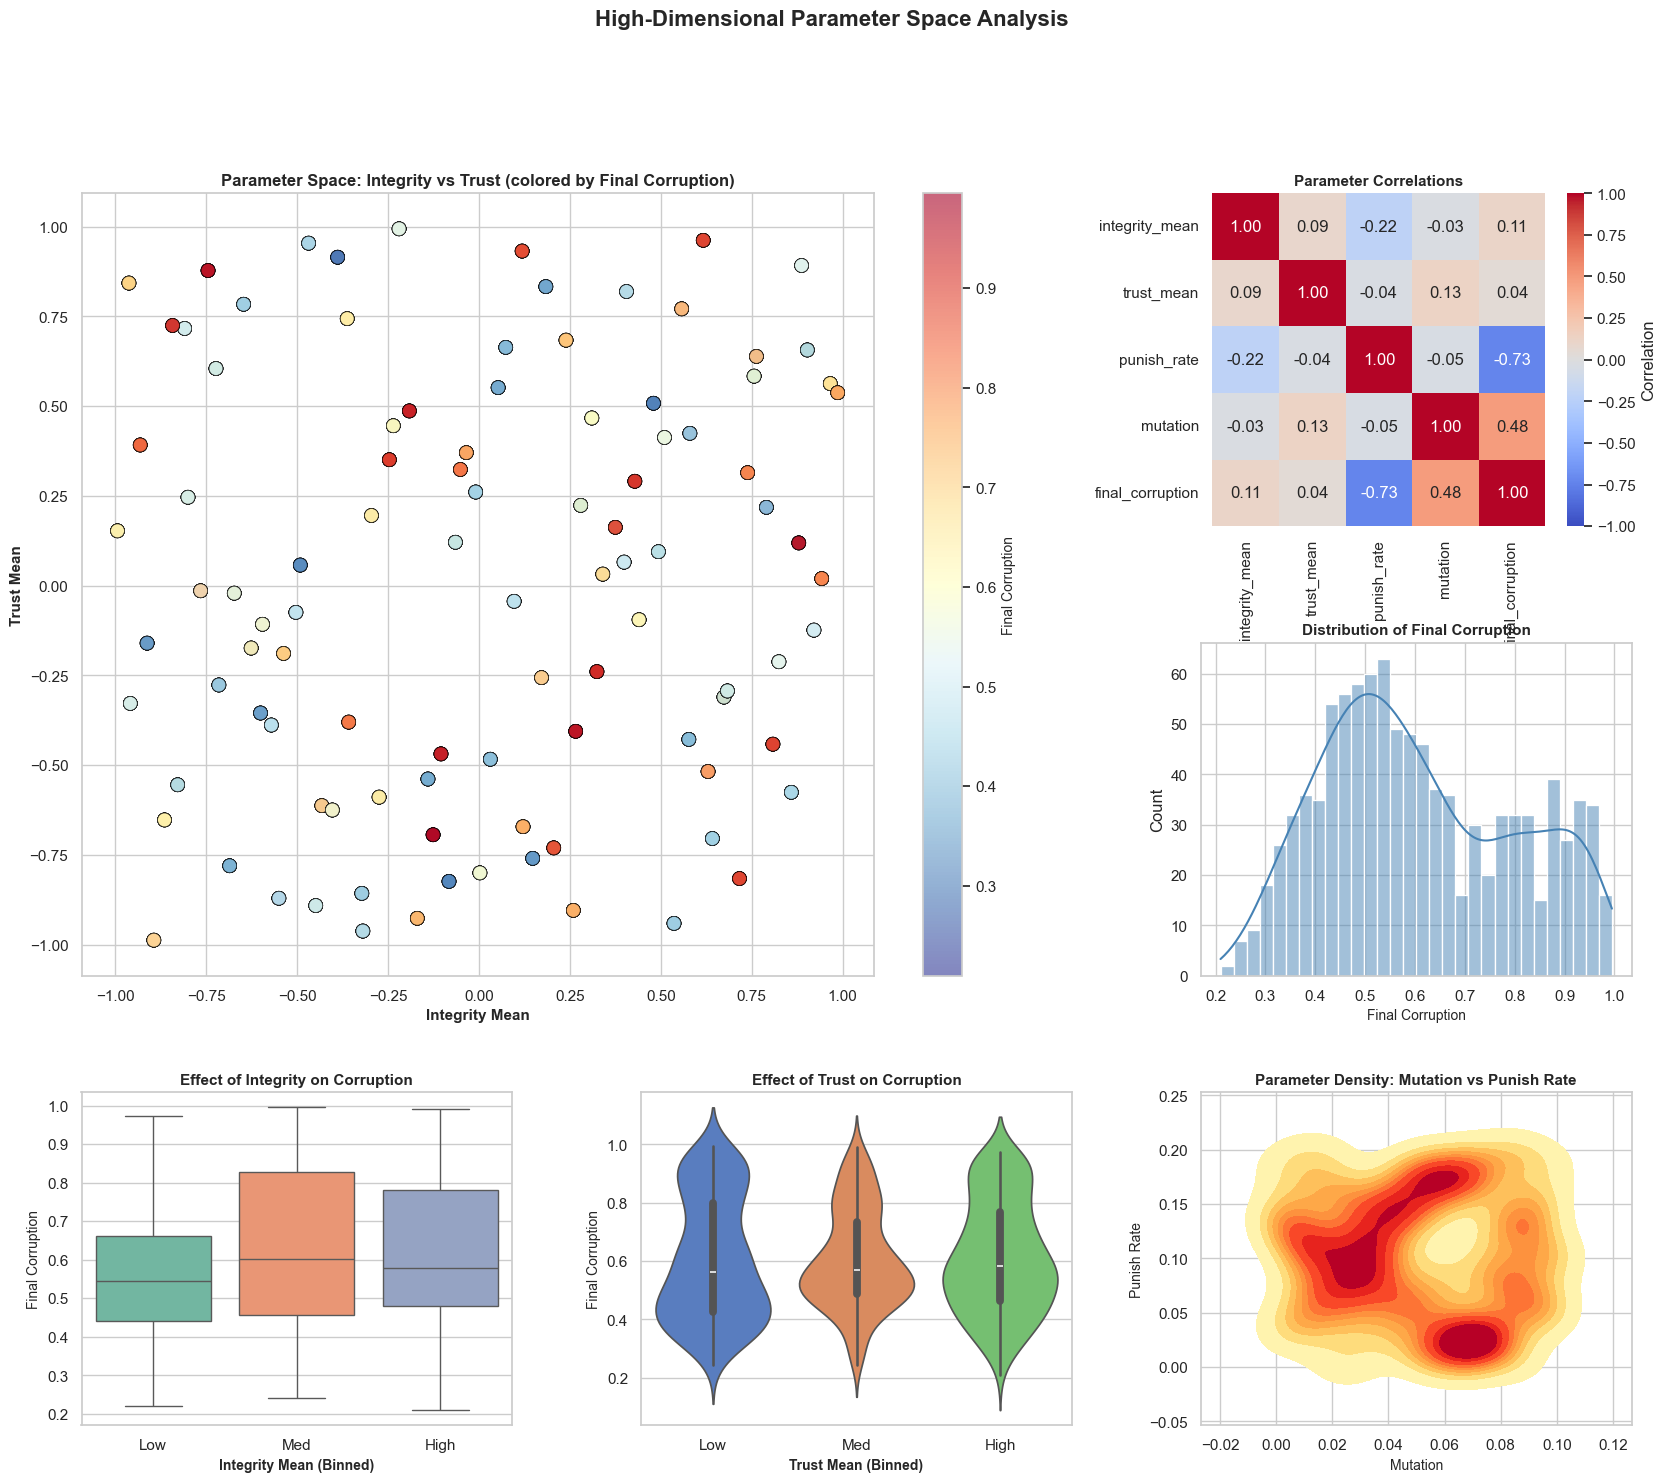


Generating Pairplot of All Parameters...



<Figure size 1400x1200 with 0 Axes>

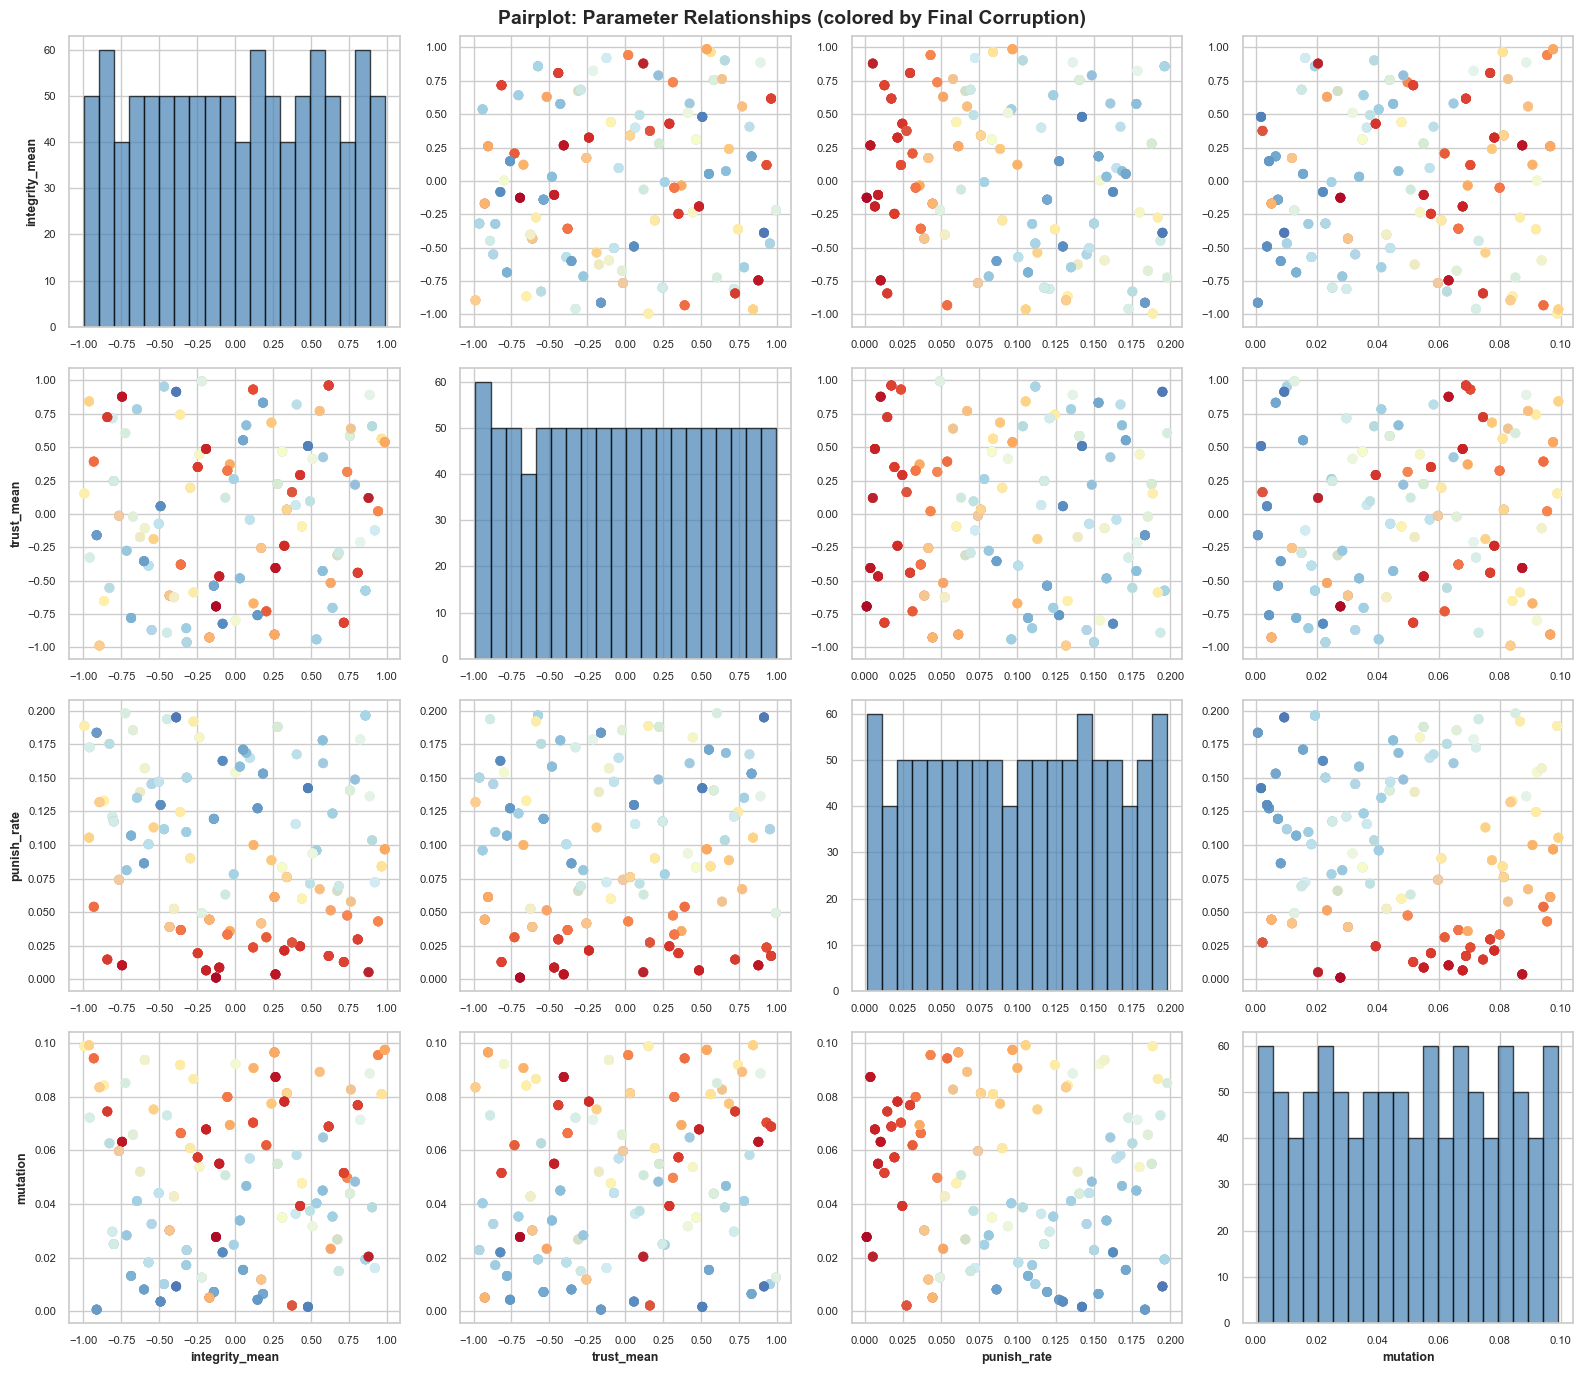


Visualization complete! The plots show:
  • How parameters are distributed and correlated
  • Effects of individual parameters on final corruption levels
  • Joint effects of parameter pairs
  • Parameter density and sampling coverage from LHS sweep


In [68]:
import seaborn as sns
# Set seaborn style for better aesthetics
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (14, 10)

# Create figure with multiple subplot areas
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Pairplot-style scatter plots with final_corruption as hue
ax1 = fig.add_subplot(gs[0:2, 0:2])
param_cols = ['integrity_mean', 'trust_mean', 'punish_rate', 'mutation']
summary_norm = summary.copy()
summary_norm[param_cols] = (summary[param_cols] - summary[param_cols].mean()) / summary[param_cols].std()

# Create scatter of first two principal-ish params, colored by corruption
scatter = ax1.scatter(summary['integrity_mean'], summary['trust_mean'], 
                      c=summary['final_corruption'], s=100, alpha=0.6, cmap='RdYlBu_r', edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Integrity Mean', fontsize=11, fontweight='bold')
ax1.set_ylabel('Trust Mean', fontsize=11, fontweight='bold')
ax1.set_title('Parameter Space: Integrity vs Trust (colored by Final Corruption)', fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(scatter, ax=ax1)
cbar1.set_label('Final Corruption', fontsize=10)

# 2. Heatmap of parameter correlations with final_corruption
ax2 = fig.add_subplot(gs[0, 2])
corr_data = summary[param_cols + ['final_corruption']].corr()
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax2, 
            cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1, square=True)
ax2.set_title('Parameter Correlations', fontsize=11, fontweight='bold')

# 3. Distribution of final corruption across runs
ax3 = fig.add_subplot(gs[1, 2])
sns.histplot(summary['final_corruption'], kde=True, ax=ax3, bins=30, color='steelblue')
ax3.set_xlabel('Final Corruption', fontsize=10)
ax3.set_title('Distribution of Final Corruption', fontsize=11, fontweight='bold')

# 4. Box plots: final_corruption by discretized integrity_mean
ax4 = fig.add_subplot(gs[2, 0])
summary['integrity_bin'] = pd.cut(summary['integrity_mean'], bins=3, labels=['Low', 'Med', 'High'])
sns.boxplot(data=summary, x='integrity_bin', y='final_corruption', ax=ax4, palette='Set2')
ax4.set_xlabel('Integrity Mean (Binned)', fontsize=10, fontweight='bold')
ax4.set_ylabel('Final Corruption', fontsize=10)
ax4.set_title('Effect of Integrity on Corruption', fontsize=11, fontweight='bold')

# 5. Violin plot: final_corruption by discretized trust_mean
ax5 = fig.add_subplot(gs[2, 1])
summary['trust_bin'] = pd.cut(summary['trust_mean'], bins=3, labels=['Low', 'Med', 'High'])
sns.violinplot(data=summary, x='trust_bin', y='final_corruption', ax=ax5, palette='muted')
ax5.set_xlabel('Trust Mean (Binned)', fontsize=10, fontweight='bold')
ax5.set_ylabel('Final Corruption', fontsize=10)
ax5.set_title('Effect of Trust on Corruption', fontsize=11, fontweight='bold')

# 6. 2D KDE plot: mutation vs punish_rate
ax6 = fig.add_subplot(gs[2, 2])
sns.kdeplot(data=summary, x='mutation', y='punish_rate', ax=ax6, cmap='YlOrRd', fill=True, thresh=0.05)
ax6.set_title('Parameter Density: Mutation vs Punish Rate', fontsize=11, fontweight='bold')
ax6.set_xlabel('Mutation', fontsize=10)
ax6.set_ylabel('Punish Rate', fontsize=10)

plt.suptitle('High-Dimensional Parameter Space Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Additional: Create a comprehensive pairplot for all parameters
print("\n" + "="*60)
print("Generating Pairplot of All Parameters...")
print("="*60 + "\n")

fig2 = plt.figure(figsize=(14, 12))
# Create smaller pairplot manually with corruption as hue
pairplot_data = summary[param_cols + ['final_corruption']].copy()

# Create grid of scatter plots
n_params = len(param_cols)
fig3, axes = plt.subplots(n_params, n_params, figsize=(16, 14))

for i, param1 in enumerate(param_cols):
    for j, param2 in enumerate(param_cols):
        ax = axes[i, j]
        
        if i == j:
            # Diagonal: histogram
            ax.hist(summary[param1], bins=20, alpha=0.7, color='steelblue', edgecolor='black')
            ax.set_ylabel('Count', fontsize=9)
        else:
            # Off-diagonal: scatter with corruption as color
            scatter = ax.scatter(summary[param2], summary[param1], 
                               c=summary['final_corruption'], s=50, alpha=0.5, 
                               cmap='RdYlBu_r', edgecolors='none')
        
        # Labels
        if i == n_params - 1:
            ax.set_xlabel(param2, fontsize=9, fontweight='bold')
        else:
            ax.set_xlabel('', fontsize=8)
            
        if j == 0:
            ax.set_ylabel(param1, fontsize=9, fontweight='bold')
        else:
            ax.set_ylabel('', fontsize=8)
        
        ax.tick_params(labelsize=8)

plt.suptitle('Pairplot: Parameter Relationships (colored by Final Corruption)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nVisualization complete! The plots show:")
print("  • How parameters are distributed and correlated")
print("  • Effects of individual parameters on final corruption levels")
print("  • Joint effects of parameter pairs")
print("  • Parameter density and sampling coverage from LHS sweep")


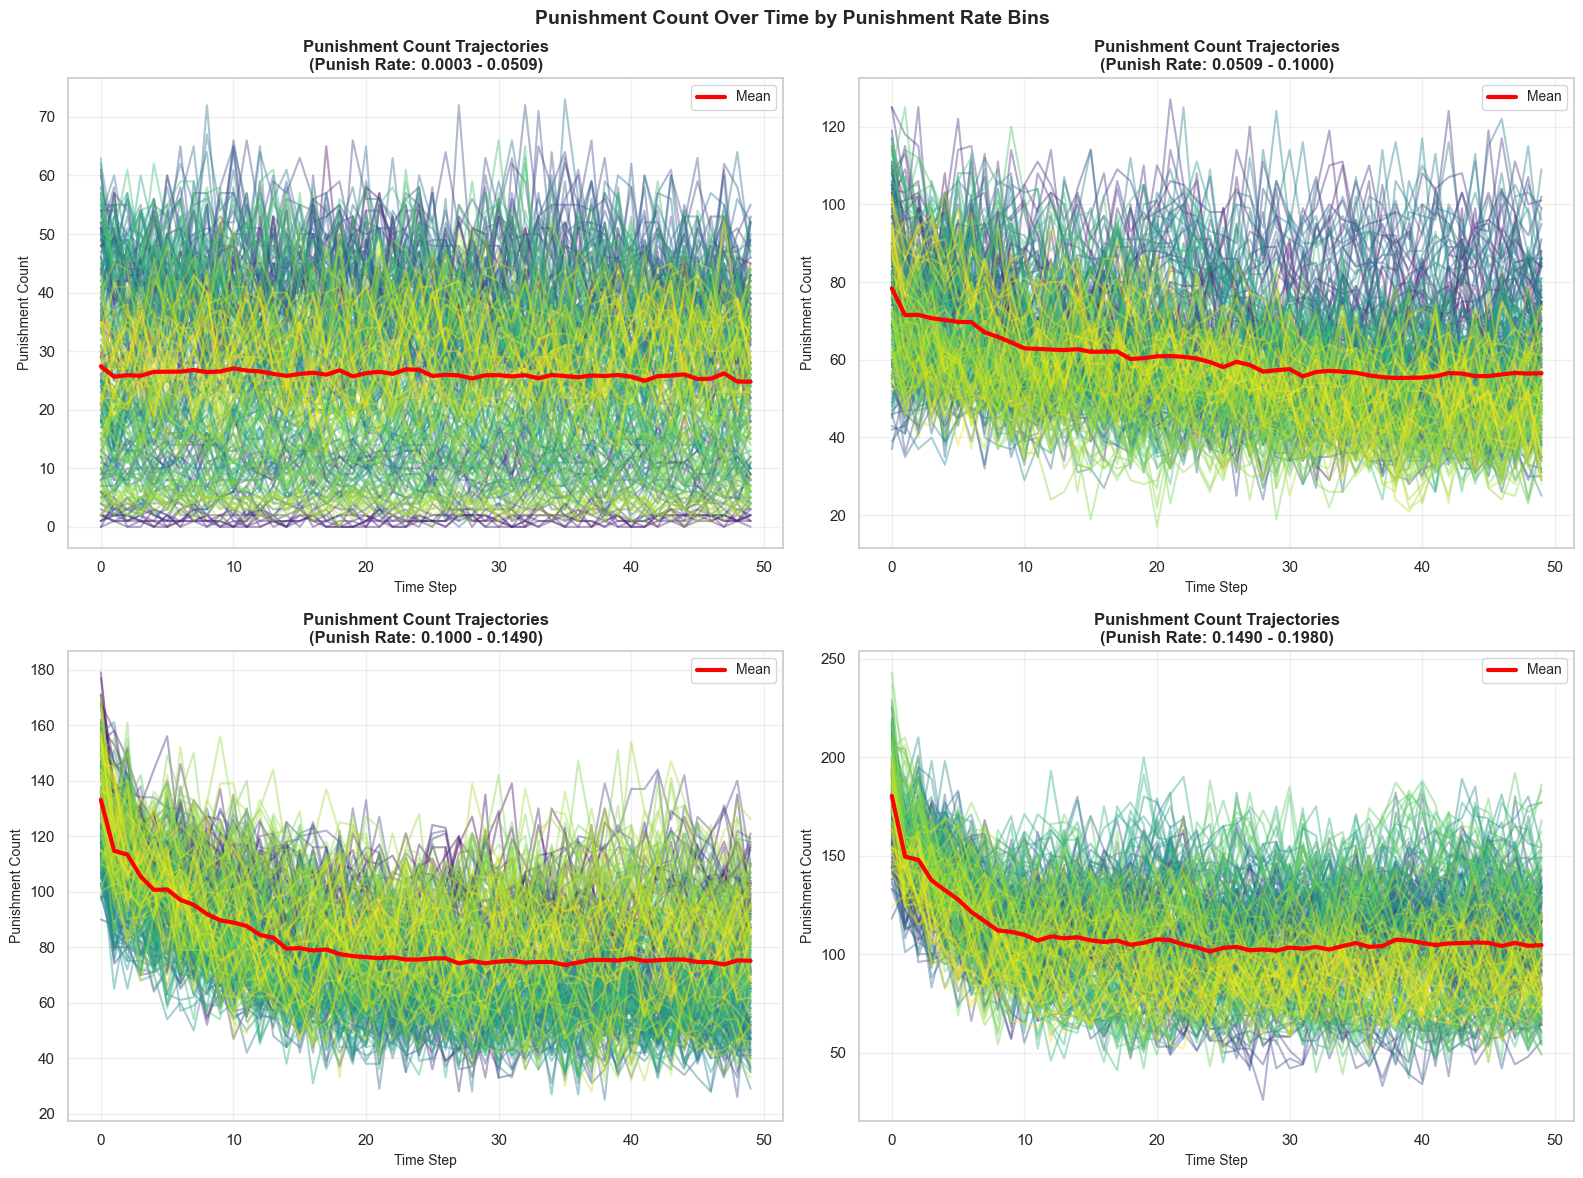


Punishment Statistics by Punish Rate Bin:

Punish Rate Range: 0.0003 - 0.0509
  Number of runs: 250
  Final corruption (mean ± std): 0.851 ± 0.117

Punish Rate Range: 0.0509 - 0.1000
  Number of runs: 250
  Final corruption (mean ± std): 0.613 ± 0.136

Punish Rate Range: 0.1000 - 0.1490
  Number of runs: 250
  Final corruption (mean ± std): 0.488 ± 0.122

Punish Rate Range: 0.1490 - 0.1980
  Number of runs: 250
  Final corruption (mean ± std): 0.480 ± 0.104


In [70]:
# Plot punishment count trajectories binned by punish_rate

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Create bins for punish_rate using quantile-based binning
punish_rate_bins = pd.qcut(summary['punish_rate'], q=4, duplicates='drop')
unique_bins = punish_rate_bins.unique()

# Plot trajectories by punish_rate bin
bin_idx = 0
for bin_interval in sorted(unique_bins):
    if bin_idx >= len(axes):
        break
    
    ax = axes[bin_idx]
    
    # Get rows in this bin
    bin_mask = punish_rate_bins == bin_interval
    bin_rows = summary[bin_mask]
    bin_indices = bin_rows.index.tolist()
    
    # Create title with punish_rate range
    ax.set_title(f'Punishment Count Trajectories\n(Punish Rate: {bin_interval.left:.4f} - {bin_interval.right:.4f})', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Step', fontsize=10)
    ax.set_ylabel('Punishment Count', fontsize=10)
    
    # Plot trajectories for this bin
    colors = plt.cm.viridis(np.linspace(0, 1, len(bin_indices)))
    mean_punish = None
    
    for color_idx, result_idx in enumerate(bin_indices):
        result = results[result_idx]
        punish_counts = result['model_data']['count_punished'].values
        time_steps = result['model_data']['time_step'].values
        ax.plot(time_steps, punish_counts, alpha=0.4, linewidth=1.5, color=colors[color_idx])
        
        # Accumulate for mean
        if mean_punish is None:
            mean_punish = np.zeros_like(punish_counts, dtype=float)
        mean_punish += punish_counts
    
    # Add mean trajectory in bold
    if mean_punish is not None and len(bin_indices) > 0:
        mean_punish /= len(bin_indices)
        ax.plot(time_steps, mean_punish, color='red', linewidth=3, label='Mean', zorder=10)
        ax.legend(fontsize=10)
    
    ax.grid(True, alpha=0.3)
    bin_idx += 1

plt.suptitle('Punishment Count Over Time by Punishment Rate Bins', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics by punish_rate bin
print("\nPunishment Statistics by Punish Rate Bin:")
print("="*70)
for bin_interval in sorted(unique_bins):
    bin_mask = punish_rate_bins == bin_interval
    bin_group = summary[bin_mask]
    
    print(f"\nPunish Rate Range: {bin_interval.left:.4f} - {bin_interval.right:.4f}")
    print(f"  Number of runs: {len(bin_group)}")
    print(f"  Final corruption (mean ± std): {bin_group['final_corruption'].mean():.3f} ± {bin_group['final_corruption'].std():.3f}")
